# Tarea 0 — IELE756

Team members: Gaspar Lämmel Romo, Fernando Rodriguez Reyes
Region: [Región ##]  
Date: 2026-03-06

En este notebook vamos a hacer un primer contacto con los tres datasets
que usaremos durante el curso:

1. Censo 2024
2. ENO (Enfermedades de notificación obligatoria)
3. GRD (Egresos hospitalarios)

El objetivo de esta tarea no es hacer un análisis profundo todavía,
sino asegurarnos de que podemos cargar los datos, revisarlos y
filtrarlos para nuestra región usando Python y pandas.

## Parte 0 — Setup

Primero importamos las librerías principales que vamos a usar.

- **pandas** nos permite cargar y manipular datasets.
- **matplotlib** lo usaremos para hacer algunos gráficos simples.

También imprimimos la versión de pandas para confirmar que todo está funcionando bien.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.2.2


## Parte 1 — Censo 2024

Los microdatos del Censo 2024 están guardados en formato **Parquet**.

Este formato es eficiente para trabajar con datasets grandes porque
almacena la información por columnas.

Como el dataset completo es muy grande, vamos a cargar solo las columnas
que necesitamos para esta tarea.

In [26]:
import pandas as pd
persona = pd.read_parquet(
"personas_censo2024.parquet",
columns=["region", "comuna", "sexo", "edad",
"p27_nacionalidad", "p27_nacionalidad_rec",
"escolaridad", "sit_fuerza_trabajo"],
)

Una vez cargado el dataset, lo primero es inspeccionarlo para entender
su estructura.

Usamos algunas funciones básicas de pandas:

- **shape** → muestra cuántas filas y columnas tiene el dataset
- **dtypes** → muestra el tipo de dato de cada columna
- **head()** → muestra las primeras filas
- **info()** → entrega información general del dataset, incluyendo valores faltantes

Esto nos ayuda a entender rápidamente con qué tipo de datos estamos trabajando.

In [27]:
print(f"Total personas: {len(persona):,}")
print(persona.dtypes)

Total personas: 18,480,432
region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object


In [28]:
persona.shape

(18480432, 8)

In [29]:
persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


In [30]:
persona.dtypes

region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

In [31]:
persona.head(10)

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [32]:
persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


En el dataset del Censo, las regiones están representadas usando
**códigos numéricos**.

Por ejemplo:

- 1 → Tarapacá
- 13 → Región Metropolitana

Para continuar el análisis, filtramos el dataset para quedarnos solo
con las personas que pertenecen a nuestra región asignada.

In [33]:
my_region = persona[persona["region"] == 13]

print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 7,400,741


Ahora vamos a mirar la distribución de nacionalidad usando la variable
**p27_nacionalidad_rec**.

Con `value_counts(normalize=True)` podemos calcular el porcentaje de
cada categoría dentro de la región.

Esto nos permite estimar el porcentaje de personas extranjeras
que viven en la región.

In [34]:
foreign = my_region["p27_nacionalidad_rec"].value_counts(normalize=True)
print(f"% foreign-born: {foreign.get('Extranjero', 0):.1%}")

% foreign-born: 0.0%


In [35]:
# Variable recodificada (más conveniente) Códigos: 1=Chileno, 2=Chileno+otra, 3=Extranjero, -99=NR
print(my_region["p27_nacionalidad_rec"].value_counts())
foreign = my_region["p27_nacionalidad_rec"] \
.value_counts(normalize=True)
print(f"% extranjeros: {foreign.get('Extranjero', 0):.1%}")

p27_nacionalidad_rec
 1     6446621
 2      904819
-99      49301
Name: count, dtype: int64
% extranjeros: 0.0%


## Parte 2 — ENO (Enfermedades de Notificación Obligatoria)

El dataset ENO contiene registros de enfermedades que deben ser
notificadas obligatoriamente al sistema de salud.

El archivo está en formato **CSV** y utiliza **punto y coma (;)**
como separador.

Primero cargamos el dataset y revisamos su tamaño y las columnas que contiene.

In [36]:
eno = pd.read_csv("20241218_base_eno_final.csv",sep=";", encoding="utf-8-sig")
print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())

C:\Users\Gaspar\AppData\Local\Temp\ipykernel_2220\1189242726.py:1: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv("20241218_base_eno_final.csv",sep=";", encoding="utf-8-sig")


Total rows: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


A diferencia del Censo, en el dataset ENO las regiones no están
codificadas con números, sino con **texto**.

Por ejemplo:

"Región Metropolitana"

Por lo tanto, filtramos usando el nombre de la región.

In [37]:
eno_region = eno[eno["region"] == "Región Metropolitana de Santiago"]

print(f"Rows in my region: {len(eno_region):,}")

Rows in my region: 126,669


Ahora queremos ver cuántas notificaciones de enfermedades existen
por año en nuestra región.

Para esto usamos la columna **anho_notificacion** y contamos
la cantidad de registros por año.

Luego mostramos los resultados en un gráfico de barras para
visualizar mejor la tendencia.

In [38]:
eno_region["anho_notificacion"].value_counts().sort_index()

anho_notificacion
2007     3930
2008     3830
2009     4015
2010     4693
2011     6151
2012     5857
2013     6006
2014     6005
2015     6129
2016     6023
2017    10865
2018    13256
2019    10287
2020     7182
2021     7457
2022    10496
2023     9395
2024     5092
Name: count, dtype: int64

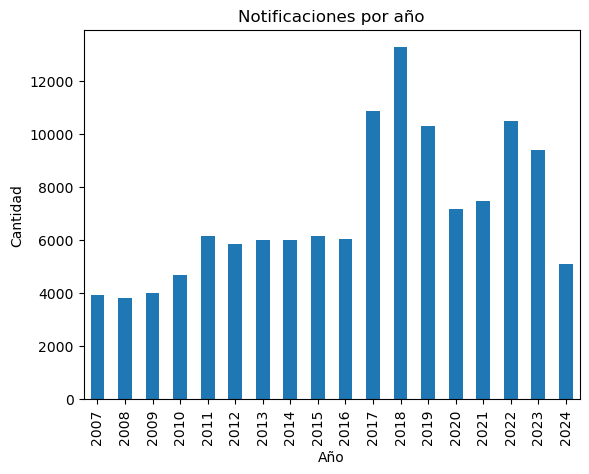

In [39]:
cases_year = eno_region["anho_notificacion"].value_counts().sort_index()

cases_year
cases_year.plot(kind="bar")

plt.title("Notificaciones por año")
plt.xlabel("Año")
plt.ylabel("Cantidad")

plt.show()

Aquí identificamos las **5 enfermedades más notificadas**
en nuestra región.

Primero contamos cuántas veces aparece cada enfermedad en la
columna **ENO**.

Luego mostramos el resultado en un gráfico de barras horizontales.

In [40]:
top_diseases = eno_region["ENO"].value_counts().head(5)

top_diseases

ENO
Sifilis                 40928
VIH                     29097
Parotiditis             15493
Infección gonocócica     8766
Hepatitis B              7565
Name: count, dtype: int64

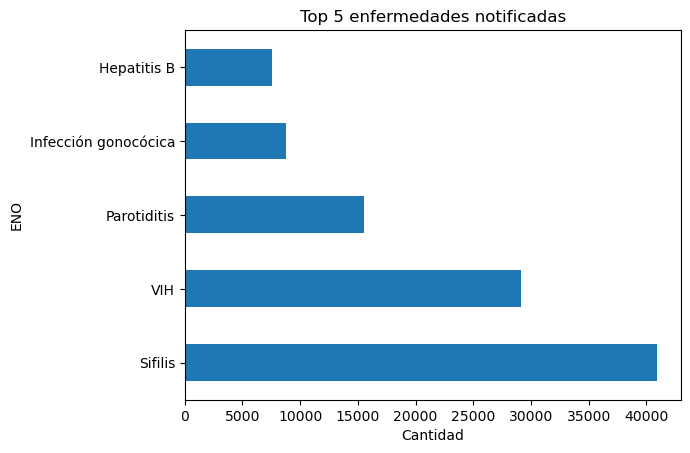

In [41]:
top_diseases.plot(kind="barh")

plt.title("Top 5 enfermedades notificadas")
plt.xlabel("Cantidad")

plt.show()

El dataset ENO también incluye una variable de **nacionalidad**.

Es común encontrar una categoría llamada **"Desconocido"**.

Siguiendo las instrucciones de la tarea, reportamos esta categoría
tal como aparece en los datos y no la eliminamos del análisis.

In [42]:
eno_region["nacionalidad"].value_counts()

nacionalidad
Desconocido    55863
Chile          47093
Extranjero     23713
Name: count, dtype: int64

Tambien podemos aplicar lo mismo para los Extranjeros.

In [43]:
eno_region[eno_region["nacionalidad"] == "Extranjero"] \
["ENO"].value_counts().head()

ENO
VIH                     7974
Hepatitis B             6545
Sifilis                 6202
Infección gonocócica     654
Parotiditis              544
Name: count, dtype: int64

## Parte 3 — GRD (Egresos Hospitalarios)

El dataset GRD contiene información sobre egresos hospitalarios.

Cada archivo:

- está comprimido en un archivo ZIP
- usa **; (pipe)** como separador
- contiene más de 100 columnas

Para evitar problemas de memoria, vamos a cargar solamente las
columnas que necesitamos para esta tarea.

In [17]:
import zipfile
import pandas as pd

cols = [
    "COMUNA",
    "NACIONALIDAD",
    "SEXO",
    "DIAGNOSTICO1",
    "FECHA_INGRESO",
    "FECHAALTA",
    "IR_29301_SEVERIDAD",
    "IR_29301_COD_GRD"
]

with zipfile.ZipFile("GRD_PUBLICO_2024.zip") as z:
    nombre_interno = z.namelist()[0]
    print("Archivo interno:", nombre_interno)
    with z.open(nombre_interno) as f:
        grd = pd.read_csv(
            f,
            sep="|",
            usecols=cols,
            low_memory=False,
            encoding="latin-1"
        )

print(f"Total discharges: {len(grd):,}")
print(grd.head(10))

Archivo interno: GRD_PUBLICO_2024.txt
Total discharges: 1,085,813
     SEXO               COMUNA NACIONALIDAD FECHA_INGRESO   FECHAALTA  \
0   MUJER        VILLA ALEMANA        CHILE    2024-03-23  2024-03-23   
1   MUJER         VIÑA DEL MAR        CHILE    2024-09-26  2024-10-02   
2  HOMBRE            LA SERENA        CHILE    2024-01-22  2024-01-26   
3  HOMBRE                ÑUÑOA        CHILE    2024-04-08  2024-04-14   
4   MUJER  SAN PEDRO DE LA PAZ         PERÚ    2024-09-24  2024-09-26   
5   MUJER                 TOME        CHILE    2024-01-05  2024-01-05   
6   MUJER           CONCEPCIÓN        CHILE    2024-12-05  2024-12-16   
7  HOMBRE           SAN FELIPE        CHILE    2024-08-31  2024-08-31   
8   MUJER         PUNTA ARENAS        CHILE    2024-01-03  2024-01-05   
9   MUJER         PUNTA ARENAS        CHILE    2023-12-31  2024-01-03   

  DIAGNOSTICO1 IR_29301_COD_GRD IR_29301_SEVERIDAD  
0        H26.9           022360                  0  
1        M31.1          

In [18]:
comunas = [
    "SANTIAGO", "PROVIDENCIA", "LAS CONDES", "MAIPU", "LA FLORIDA",
    "PUENTE ALTO", "SAN BERNARDO", "ÑUÑOA", "LA PINTANA", "EL BOSQUE",
    "PUDAHUEL", "PEÑALOLEN", "QUILICURA", "RECOLETA", "INDEPENDENCIA",
    "MACUL", "SAN MIGUEL", "LO BARNECHEA", "VITACURA", "CERRILLOS",
    "CERRO NAVIA", "CONCHALÍ", "ESTACION CENTRAL", "HUECHURABA",
    "LA CISTERNA", "LA GRANJA", "LA REINA", "LO ESPEJO", "LO PRADO",
    "PADRE HURTADO", "PEDRO AGUIRRE CERDA", "PIRQUE", "RENCA",
    "SAN JOAQUIN", "SAN JOSE DE MAIPO", "SAN RAMON", "TALAGANTE",
    "BUIN", "CALERA DE TANGO", "EL MONTE", "ISLA DE MAIPO",
    "MELIPILLA", "PAINE", "PEÑAFLOR", "TIL TIL", "COLINA",
    "LAMPA", "MARIA PINTO", "CURACAVI", "ALHUE", "SAN PEDRO"
]

grd_region = grd[grd["COMUNA"].isin(comunas)]
print(f"Discharges en Región Metropolitana: {len(grd_region):,}")

Discharges en Región Metropolitana: 308,281


In [19]:
cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10")

grd_region["DIAGNOSTICO1"] = grd_region["DIAGNOSTICO1"].apply(
    lambda x: x[:-1] + "." + x[-1] 
    if isinstance(x, str) and "." not in x and len(x) > 3 
    else x
)

grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1", right_on="Código",
    how="left"
)

print(f"Filas después del merge: {len(grd_region):,}")
nans = grd_region["Descripción"].isna().sum()
print(f"Diagnósticos sin match: {nans:,} ({nans/len(grd_region):.1%})")
print(grd_region[["DIAGNOSTICO1", "Descripción", "Capítulo"]].head(10))

Filas después del merge: 308,281
Diagnósticos sin match: 8 (0.0%)
  DIAGNOSTICO1                                        Descripción  \
0          C61                       Tumor maligno de la próstata   
1       S72.10                 Fractura pertrocanteriana, cerrada   
2        T29.2  Quemaduras de múltiples regiones, mencionadas ...   
3        K72.0            Insuficiencia hepática aguda o subaguda   
4        J35.3  Hipertrofia de las amígdalas con hipertrofia d...   
5        A41.9                             Sepsis no especificada   
6        J15.1                      Neumonía debida a Pseudomonas   
7        K35.8          Apendicitis aguda, otra y no especificada   
8        L03.1          Celulitis de otras partes de los miembros   
9        Z51.2                                 Otra quimioterapia   

                                            Capítulo  
0                       Cap.02  NEOPLASIAS (C00-D49)  
1  Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...  
2  Cap.19

C:\Users\Gaspar\AppData\Local\Temp\ipykernel_25048\495408890.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grd_region["DIAGNOSTICO1"] = grd_region["DIAGNOSTICO1"].apply(


Descripción
Catarata, no especificada                             10075
Cálculo de la vesícula biliar sin colecistitis         4972
Apendicitis aguda, otra y no especificada              4650
Catarata senil, no especificada                        3233
Desgarro perineal de primer grado durante el parto     3018
Name: count, dtype: int64


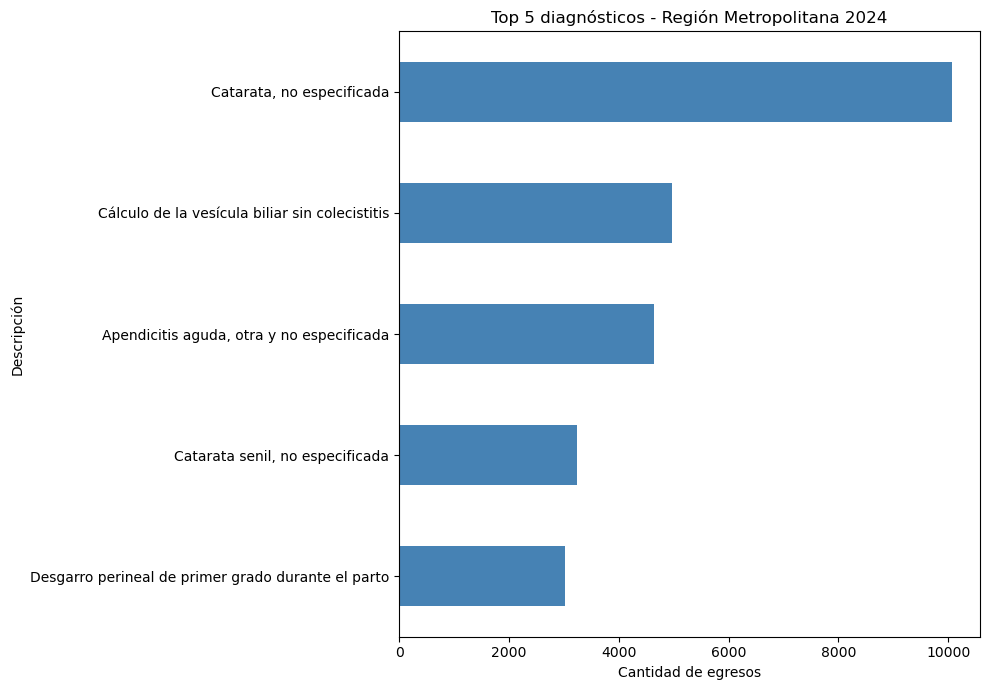

In [20]:
#Top 5 diagnósticos
import matplotlib.pyplot as plt

top5 = grd_region["Descripción"].value_counts().head(5)
print(top5)

fig, ax = plt.subplots(figsize=(10, 7))
top5.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 5 diagnósticos - Región Metropolitana 2024")
ax.set_xlabel("Cantidad de egresos")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Resumen

En esta tarea logramos hacer un primer contacto con los tres datasets
principales del curso para la **Región Metropolitana de Santiago**.

**Censo 2024** — Cargamos el archivo parquet con 18,480,432 personas a nivel
nacional y filtramos a la Región Metropolitana. Inspeccionamos la estructura
del dataset y calculamos el porcentaje de personas extranjeras en la región.

**ENO** — Cargamos la base de enfermedades de notificación obligatoria
(2007–2024) y filtramos a la Región Metropolitana. Visualizamos la evolución
de notificaciones por año y las 5 enfermedades más frecuentes (VIH,
Hepatitis B, Sífilis, Infección gonocócica y Parotiditis). También
revisamos la distribución de nacionalidad, incluyendo la categoría "Desconocido".

**GRD** — Cargamos el archivo oficial GRD_PUBLICO_2024.zip con datos de
egresos hospitalarios. El archivo usa separador pipe (|), codificación
latin-1 y contiene 129 columnas, por lo que cargamos solo las necesarias.
Filtramos a la Región Metropolitana usando los nombres de comunas en
mayúsculas. Luego tradujimos los códigos ICD-10 de la columna DIAGNOSTICO1
al formato estándar con punto (ej: K358 → K35.8) para hacer el join con
la tabla CIE-10.xlsx y obtener los nombres y capítulos de cada diagnóstico.
Finalmente visualizamos los 5 diagnósticos más frecuentes en la región.

Un desafío importante fue que cada dataset usa convenciones distintas:
el Censo identifica la región con un código numérico (13), el ENO con
texto ("Región Metropolitana de Santiago"), y el GRD no tiene columna
de región — se filtra por nombre de comuna en MAYÚSCULAS. Además, los
códigos ICD-10 del GRD no incluyen el punto decimal, lo que requirió
un paso adicional de formateo antes del merge con CIE-10.

In [2]:
print("🎉 Tarea 0 completada exitosamente!")
print("📊 Datasets cargados: Censo 2024, ENO, GRD")
print("📍 Región: Metropolitana de Santiago")

🎉 Tarea 0 completada exitosamente!
📊 Datasets cargados: Censo 2024, ENO, GRD
📍 Región: Metropolitana de Santiago
